In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [5]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [7]:
# imputing using pandas
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [8]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [9]:
X_train

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
331,45.5,28.5000,0,45.5,45.500000,28.5000,28.500000
733,23.0,13.0000,0,23.0,23.000000,13.0000,13.000000
382,32.0,7.9250,0,32.0,32.000000,7.9250,7.925000
704,26.0,7.8542,1,26.0,26.000000,7.8542,7.854200
813,6.0,31.2750,6,6.0,6.000000,31.2750,31.275000
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.0,21.000000,7.6500,7.650000
270,NaN,31.0000,0,28.0,29.498846,31.0000,31.000000
860,41.0,NaN,2,41.0,41.000000,14.4000,32.517788
435,14.0,120.0000,3,14.0,14.000000,120.0000,120.000000


<Axes: >

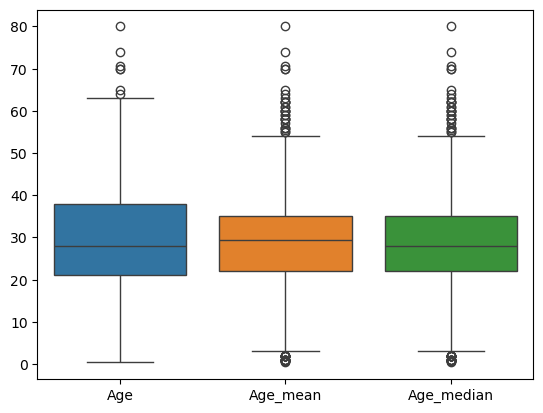

In [10]:
sns.boxplot(X_train[['Age','Age_mean','Age_median']])

<Axes: >

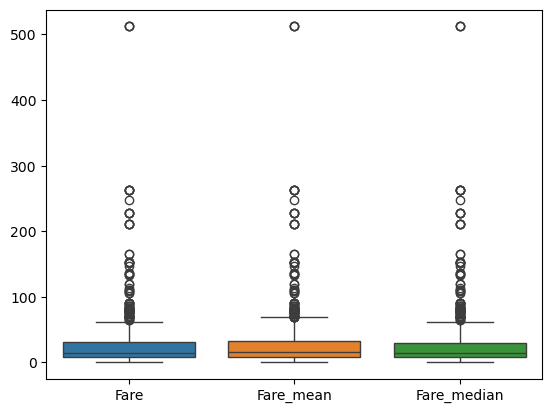

In [11]:
sns.boxplot(X_train[['Fare','Fare_mean','Fare_median']])

In [12]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [13]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


In [14]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  169.20731007048096
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  2637.01248167777
Fare Variance after mean imputation:  2621.2323749512393


In [15]:
imputer1= SimpleImputer(strategy='mean')
imputer2= SimpleImputer(strategy='median')

In [16]:
trf= ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])

])

In [17]:
trf.fit_transform(X_train)
trf.transform(X_test)

array([[ 29.49884615,  15.2458    ],
       [ 31.        ,  10.5       ],
       [ 20.        ,   7.925     ],
       [  6.        ,  33.        ],
       [ 14.        ,  11.2417    ],
       [ 26.        ,  78.85      ],
       [ 29.49884615,   7.75      ],
       [ 16.        ,  18.        ],
       [ 16.        ,   7.75      ],
       [ 19.        ,  26.2833    ],
       [ 37.        ,  53.1       ],
       [ 44.        ,   8.05      ],
       [ 29.49884615,  25.4667    ],
       [ 30.        ,   7.225     ],
       [ 36.        ,  13.        ],
       [ 16.        ,  39.4       ],
       [ 42.        ,  52.5542    ],
       [ 29.49884615,   7.8292    ],
       [ 27.        ,  13.        ],
       [ 47.        ,  52.        ],
       [ 24.        ,   7.8958    ],
       [ 34.        ,  26.55      ],
       [ 19.        ,   7.8542    ],
       [ 20.        ,   9.225     ],
       [ 29.49884615,  14.5       ],
       [ 10.        ,  27.9       ],
       [ 40.        ,  27.7208    ],
 

In [18]:
trf.named_transformers_['imputer1'].statistics_

array([29.49884615])